In [1]:
!pip install prophet

import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('train.csv')

# Converting Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate sales (Sum all store sales by date to get a global trend)
daily_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

#  columns named 'ds' (Date) and 'y' (Value)
daily_sales.columns = ['ds', 'y']

print(daily_sales.head())

          ds            y
0 2010-02-05  49750740.50
1 2010-02-12  48336677.63
2 2010-02-19  48276993.78
3 2010-02-26  43968571.13
4 2010-03-05  46871470.30


In [2]:
# Initialize Prophet with seasonality enabled
m = Prophet(weekly_seasonality=True, yearly_seasonality=True)

# Train the model
m.fit(daily_sales)

# Creating a placeholder for future dates (next 12 weeks)
future = m.make_future_dataframe(periods=12, freq='W')

# Predict
forecast = m.predict(future)

# Show the numbers
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


            ds          yhat    yhat_lower    yhat_upper
150 2012-12-16  6.699560e+07  6.245474e+07  7.138998e+07
151 2012-12-23  6.582161e+07  6.123065e+07  7.042719e+07
152 2012-12-30  5.840161e+07  5.376142e+07  6.268569e+07
153 2013-01-06  4.831415e+07  4.337842e+07  5.306388e+07
154 2013-01-13  4.153240e+07  3.713731e+07  4.587907e+07


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAPE on held-out 12-week period: 4.36%


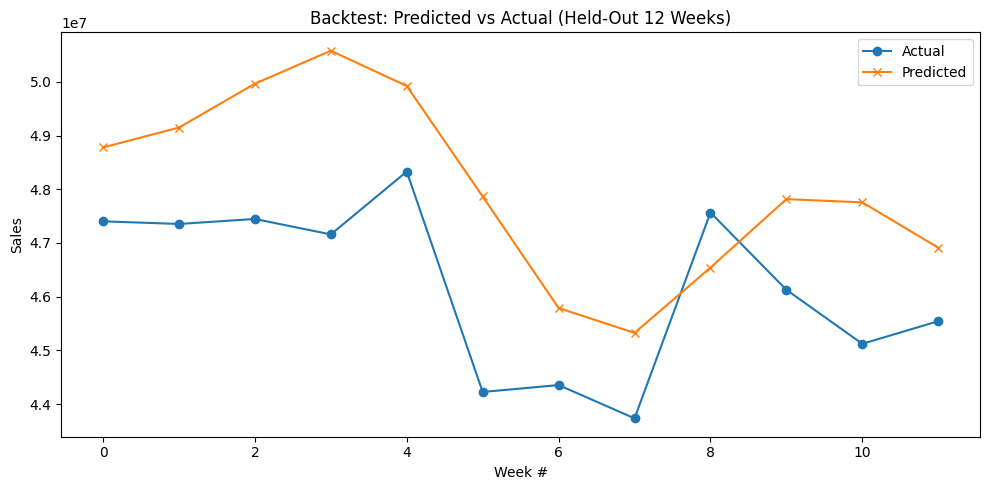

In [4]:
from sklearn.metrics import mean_absolute_percentage_error

train_size = len(daily_sales) - 12
train_data = daily_sales.iloc[:train_size]
actual_holdout = daily_sales.iloc[train_size:]

m_backtest = Prophet(weekly_seasonality=True, yearly_seasonality=True)
m_backtest.fit(train_data)

future_backtest = m_backtest.make_future_dataframe(periods=12, freq='W')
forecast_backtest = m_backtest.predict(future_backtest)

# take the LAST 12 rows of the forecast by position, not by matching exact dates —
# these are the 12 newly forecasted periods appended after the training data
predicted_holdout = forecast_backtest['yhat'].tail(12).values
actual_values = actual_holdout['y'].values

mape = mean_absolute_percentage_error(actual_values, predicted_holdout)
print(f"MAPE on held-out 12-week period: {mape:.2%}")

plt.figure(figsize=(10, 5))
plt.plot(range(12), actual_values, label='Actual', marker='o')
plt.plot(range(12), predicted_holdout, label='Predicted', marker='x')
plt.title('Backtest: Predicted vs Actual (Held-Out 12 Weeks)')
plt.xlabel('Week #')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.savefig('backtest_validation.png', dpi=150)
plt.show()

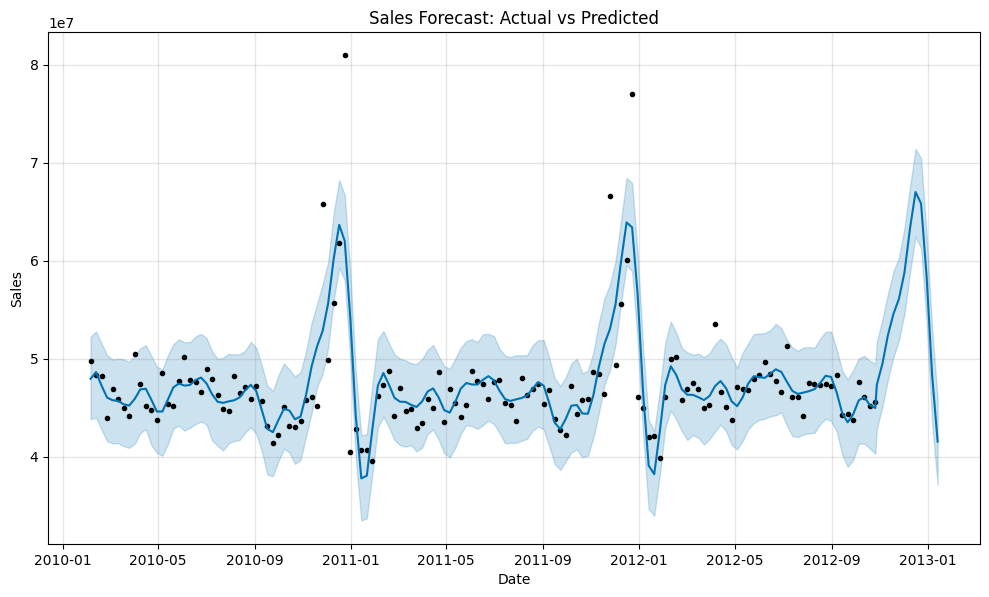

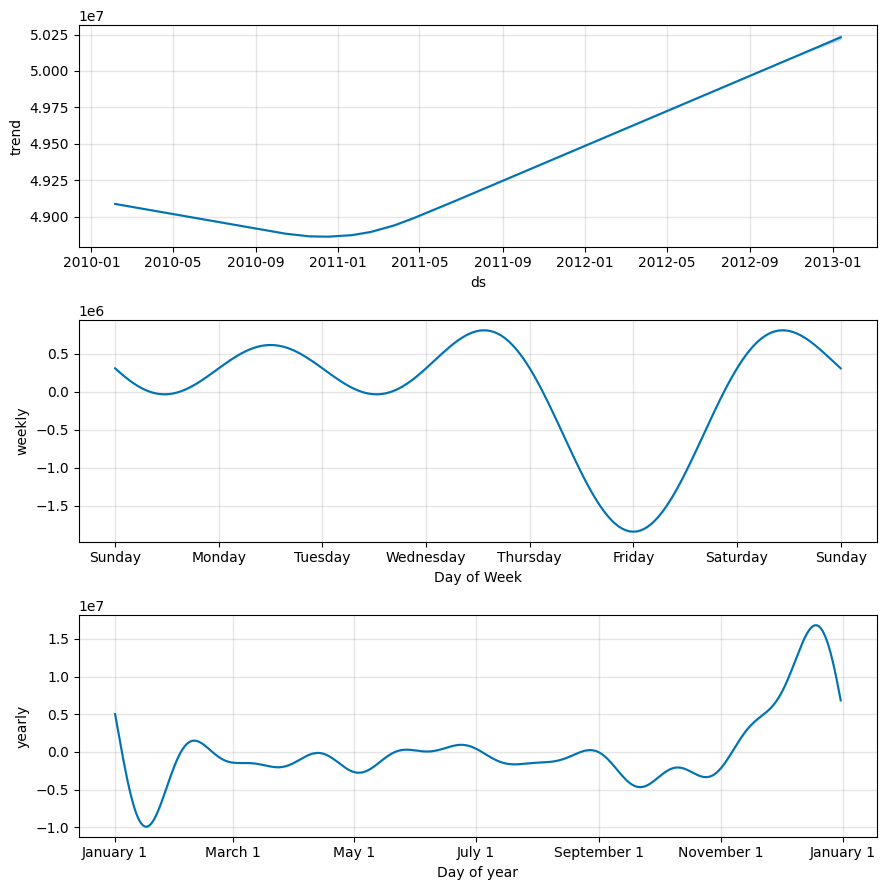

In [5]:
# Plot 1: The Main Forecast
fig1 = m.plot(forecast)
plt.title("Sales Forecast: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Plot 2: The Seasonality Breakdown (Trends)
fig2 = m.plot_components(forecast)